# Sensor Comparison

**Purpose:** Choosing the right airborne sensor for a campaign is a multi-dimensional tradeoff involving spatial resolution, swath coverage, frame rate, and aircraft performance constraints. This notebook provides a decision-support framework for comparing HyPlan's built-in airborne sensors, helping mission planners select the sensor that best matches their science requirements and operational constraints.

**Metadata:**
- **Audience:** Beginner to Intermediate
- **Runtime:** ~30 seconds
- **Requires internet:** No
- **Credentials required:** None
- **Optional dependencies:** None
- **Uses example data:** No (all values computed from sensor specifications)

**What You Will Learn:**
- How to browse HyPlan's sensor registry and interpret key specifications (FOV, IFOV, frame rate, pixel count)
- How ground sample distance (GSD), swath width, and critical ground speed scale with flight altitude
- How to determine the required altitude for a target spatial resolution
- How along-track and cross-track pixel sizes differ and why both matter
- How cross-track tilt shifts the sensor's ground footprint and when to use it
- How to use these comparisons to select the best sensor for a given science objective

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from hyplan.instruments import SENSOR_REGISTRY, create_sensor, LineScanner
from hyplan.units import ureg


## 1. Sensor Registry Overview

**The mental model:** Every line scanner has a fixed angular field of view (FOV) divided into a set number of cross-track pixels. The instantaneous field of view (IFOV) -- the angular size of a single pixel -- determines the finest spatial detail the sensor can resolve. The frame rate controls how fast the sensor scans, which in turn limits how fast the aircraft can fly before along-track gaps appear. These intrinsic properties, combined with flight altitude, determine the ground-level imaging characteristics.

List all built-in line-scanner sensors with their key specifications.

In [2]:
rows = []
for name, cls in sorted(SENSOR_REGISTRY.items()):
    sensor = cls()
    if isinstance(sensor, LineScanner):
        rows.append({
            "Sensor": sensor.name,
            "FOV (deg)": sensor.fov,
            "Pixels": sensor.across_track_pixels,
            "Frame Rate (Hz)": sensor.frame_rate.to(ureg.Hz).magnitude,
            "IFOV (mrad)": round(sensor.ifov * 1000 * np.pi / 180, 3),
        })

spec_df = pd.DataFrame(rows)
spec_df

,Sensor,FOV (deg),Pixels,Frame Rate (Hz),IFOV (mrad)
0,AVIRIS Classic,34.00,677,12.00,0.877
1,AVIRIS 3,39.60,1234,216.00,0.560
2,AVIRIS 5,40.20,1239,148.00,0.566
3,AVIRIS Next Gen,36.00,600,100.00,1.047
4,AVIRIS 3,39.60,1234,216.00,0.560
5,AVIRIS 5,40.20,1239,148.00,0.566
6,AVIRIS Classic,34.00,677,12.00,0.877
7,AVIRIS Next Gen,36.00,600,100.00,1.047
8,GCAS UV-Vis Spectrometer,45.00,1024,12.00,0.767
9,GCAS Visible Near-Infrared (VNIR) Spectrometer,70.00,1024,12.00,1.193


## 2. Ground Sample Distance vs. Altitude

**The key relationship:** Ground sample distance (GSD) -- the size of a single pixel projected onto the ground at nadir -- scales linearly with altitude above ground level (AGL). GSD = altitude x IFOV. This is the most fundamental equation in airborne remote sensing mission planning: it tells you how high you must fly to achieve a target spatial resolution, or equivalently, what resolution you get at a given altitude.

Compare nadir GSD for each sensor across a range of flight altitudes AGL.

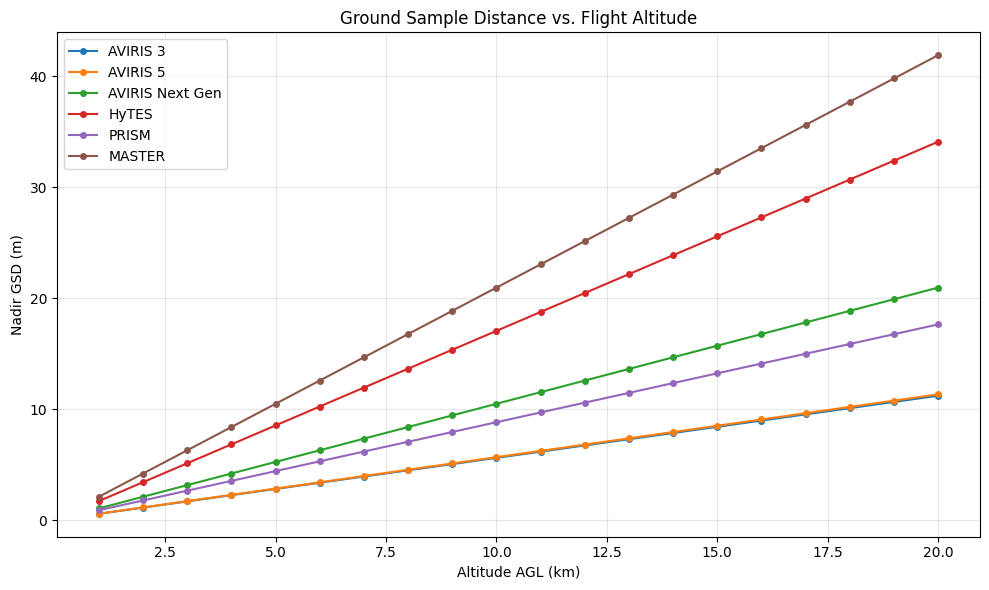

In [3]:
altitudes_m = np.arange(1000, 20001, 1000)
sensors_to_compare = ["AVIRIS-3", "AVIRIS-5", "AVIRIS-NG", "HyTES", "PRISM", "MASTER"]

fig, ax = plt.subplots(figsize=(10, 6))

for sensor_name in sensors_to_compare:
    sensor = create_sensor(sensor_name)
    gsd_vals = [
        sensor.ground_sample_distance(ureg.Quantity(alt, "meter")).to(ureg.meter).magnitude
        for alt in altitudes_m
    ]
    ax.plot(altitudes_m / 1000, gsd_vals, marker="o", markersize=4, label=sensor.name)

ax.set_xlabel("Altitude AGL (km)")
ax.set_ylabel("Nadir GSD (m)")
ax.set_title("Ground Sample Distance vs. Flight Altitude")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpreting the results:** All sensors show the expected linear GSD-altitude relationship, but with very different slopes. AVIRIS-3 and AVIRIS-5 (fine IFOV) achieve sub-meter GSD below ~2 km AGL and remain under 10 m GSD even at 20 km. MASTER and PICARD (coarse IFOV) reach 10 m GSD at only ~5 km and 40 m at 20 km. This means that if your science requires 5 m GSD, AVIRIS-3 can achieve it at ~9 km AGL (comfortable for most aircraft), while MASTER would need to fly at ~2.4 km (potentially problematic for terrain clearance or airspace). Use this plot to quickly identify which sensors can meet your resolution requirements at operationally feasible altitudes.

## 3. Swath Width vs. Altitude

**The tradeoff:** Swath width determines how much ground you cover per flight line. Wider swaths mean fewer flight lines to cover a study area (saving flight time and fuel), but wide-FOV sensors typically have coarser GSD and more severe off-nadir distortions. Swath width scales with both altitude and FOV: swath = 2 x altitude x tan(FOV/2).

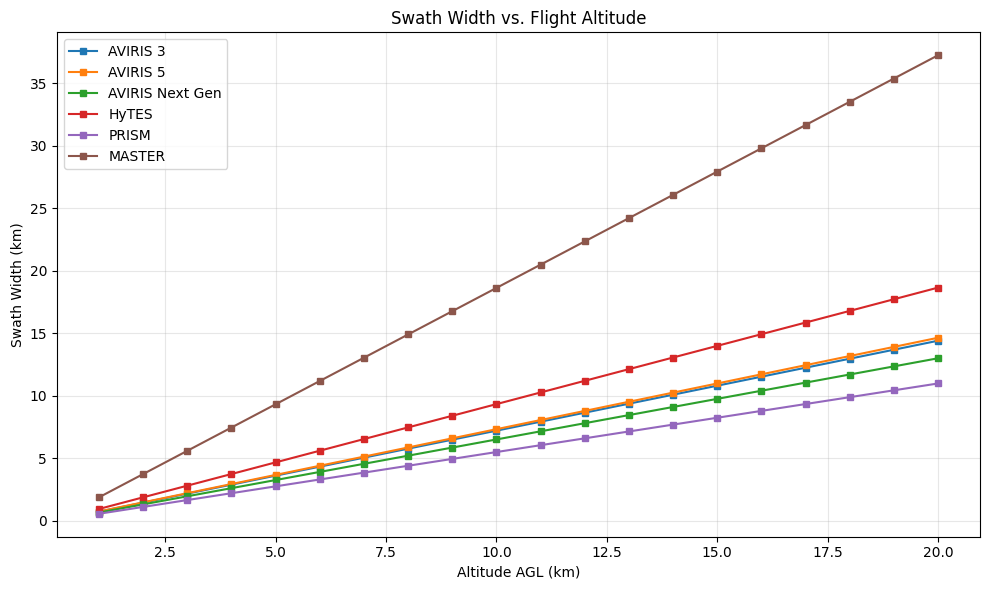

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

for sensor_name in sensors_to_compare:
    sensor = create_sensor(sensor_name)
    swath_vals = [
        sensor.swath_width(ureg.Quantity(alt, "meter")).to(ureg.km).magnitude
        for alt in altitudes_m
    ]
    ax.plot(altitudes_m / 1000, swath_vals, marker="s", markersize=4, label=sensor.name)

ax.set_xlabel("Altitude AGL (km)")
ax.set_ylabel("Swath Width (km)")
ax.set_title("Swath Width vs. Flight Altitude")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpreting the results:** MASTER's 86-degree FOV produces swath widths exceeding 40 km at 20 km altitude -- an order of magnitude wider than PRISM's ~11 km at the same altitude. For area surveys, this difference is dramatic: covering a 50 km x 50 km study area at 20 km altitude requires ~1-2 MASTER flight lines but ~5 PRISM lines. However, MASTER's wide swath comes with coarser GSD and significant geometric distortion at the swath edges. AVIRIS-3 and AVIRIS-5 sit in the middle, offering a good balance of swath width (~14 km at 20 km) and spatial resolution for most imaging spectroscopy applications.

## 4. Critical Ground Speed

**The constraint:** The critical ground speed is the maximum aircraft speed that maintains contiguous along-track sampling (no gaps between consecutive scan lines). It equals GSD x frame_rate. Exceeding this speed causes along-track under-sampling -- gaps appear between scan lines, and the data is no longer contiguous. This is often the binding constraint in flight planning: the aircraft must slow down enough for the sensor to keep up, which affects fuel burn, endurance, and turbulence sensitivity.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for sensor_name in sensors_to_compare:
    sensor = create_sensor(sensor_name)
    speed_vals = [
        sensor.critical_ground_speed(ureg.Quantity(alt, "meter")).to(ureg.knot).magnitude
        for alt in altitudes_m
    ]
    ax.plot(altitudes_m / 1000, speed_vals, marker="^", markersize=4, label=sensor.name)

ax.set_xlabel("Altitude AGL (km)")
ax.set_ylabel("Critical Ground Speed (knots)")
ax.set_title("Maximum Speed for Contiguous Along-Track Sampling")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpreting the results:** This plot reveals a critical operational distinction between sensors. AVIRIS-3's high frame rate (216 Hz) allows ground speeds exceeding 200 knots even at low altitudes, making it compatible with fast aircraft like the ER-2 or large turboprops. AVIRIS Classic's low frame rate (12 Hz) limits speeds to ~20 knots at 1 km AGL -- only feasible for slow, low-altitude platforms. MASTER and HyTES fall in between. If your aircraft has a minimum safe airspeed of 120 knots, sensors with critical ground speeds below that threshold at your planned altitude are simply not viable without accepting along-track gaps. This chart is essential for matching sensors to aircraft platforms.

## 5. Altitude Required for a Target GSD

**The planning question:** In practice, mission planners start with a science requirement ("I need 5 m GSD") and need to determine the required flight altitude. This inverts the GSD equation: altitude = GSD / IFOV. The table below answers this question for every sensor and a range of common target resolutions. This is one of the most frequently consulted references during campaign planning.

In [ ]:
target_gsds_m = [1, 2, 3, 5, 8, 10, 15, 20, 30]

rows = []
for sensor_name in sensors_to_compare:
    sensor = create_sensor(sensor_name)
    for gsd in target_gsds_m:
        alt = sensor.altitude_agl_for_ground_sample_distance(
            ureg.Quantity(gsd, "meter")
        ).to(ureg.meter).magnitude
        rows.append({
            "Sensor": sensor.name,
            "Target GSD (m)": gsd,
            "Required Altitude AGL (m)": round(alt),
        })

alt_df = pd.DataFrame(rows)
pivot = alt_df.pivot(index="Target GSD (m)", columns="Sensor", values="Required Altitude AGL (m)")
pivot

**Interpreting the results:** The table shows that achieving 1 m GSD requires very low altitudes for all sensors (477 m for MASTER, 1785 m for AVIRIS-3), which may be impractical due to terrain, airspace restrictions, or aircraft minimum altitudes. At a more comfortable 5 m GSD, AVIRIS-3 flies at 8.9 km (29,000 ft) -- well within the operating envelope of most research aircraft. For 30 m GSD (Landsat-equivalent), AVIRIS-3 would fly at 53.6 km -- far above any aircraft, confirming that airborne sensors are designed for higher resolution than satellites. Use this table to quickly filter sensors: if your aircraft cannot fly above 6 km, AVIRIS-3 is limited to GSD coarser than ~3.4 m.

## 6. Along-Track Pixel Size at Typical Airspeeds

**The asymmetry:** For pushbroom/line-scanner sensors, the cross-track pixel size is determined by IFOV and altitude (fixed by optics), while the along-track pixel size is determined by ground speed and frame rate (fixed by the scanning mechanism). These two dimensions are independent, so pixels are generally not square. The along-track pixel size equals ground_speed / frame_rate and does not depend on altitude -- it stays constant regardless of how high you fly. Achieving square pixels requires matching the aircraft speed to the sensor's critical ground speed at the chosen altitude.

In [ ]:
speed = ureg.Quantity(150, "knot")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sensor_name in sensors_to_compare:
    sensor = create_sensor(sensor_name)
    at_sizes = [
        sensor.along_track_pixel_size(speed).to(ureg.meter).magnitude
        for _ in altitudes_m
    ]
    ct_sizes = [
        sensor.ground_sample_distance(ureg.Quantity(alt, "meter")).to(ureg.meter).magnitude
        for alt in altitudes_m
    ]
    axes[0].plot(altitudes_m / 1000, at_sizes, marker="o", markersize=3, label=sensor.name)
    axes[1].plot(altitudes_m / 1000, ct_sizes, marker="o", markersize=3, label=sensor.name)

axes[0].set_xlabel("Altitude AGL (km)")
axes[0].set_ylabel("Along-Track Pixel Size (m)")
axes[0].set_title(f"Along-Track Pixel Size at {speed:~}")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Altitude AGL (km)")
axes[1].set_ylabel("Cross-Track GSD (m)")
axes[1].set_title("Cross-Track GSD (Nadir)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpreting the results:** The left panel shows that along-track pixel size is constant with altitude (flat lines), confirming it depends only on speed and frame rate. At 150 knots, AVIRIS-3 produces ~0.36 m along-track pixels and MASTER produces ~3.1 m. The right panel shows the altitude-dependent cross-track GSD. Pixels are square only where the left and right panels give equal values at the same altitude. For AVIRIS-3 at 150 knots, the along-track pixel (0.36 m) matches the cross-track GSD at an altitude of about 640 m. At higher altitudes the cross-track pixels become larger than along-track pixels, producing elongated pixels. This matters for applications like spectral unmixing where pixel shape affects sub-pixel composition estimates.

## 7. Off-Nadir (Cross-Track Tilt) Viewing

**The technique:** Line scanners can be mounted with a cross-track tilt -- a rotation about the along-track axis that shifts the sensor's ground footprint to one side of the flight track. This is operationally useful in several scenarios: avoiding sun glint over water by pointing the sensor away from the specular reflection zone, imaging steep terrain from an oblique angle, or covering a target that is offset from the aircraft's ground track. The tradeoff is that tilt increases the ground footprint width (because of the tangent function's nonlinearity) and introduces asymmetric pixel sizes across the swath.

`cross_track_tilt` is specified in degrees: positive = starboard (right), negative = port (left). The `swath_offset_angles()` method returns the viewing angles for each swath edge relative to nadir.

In [ ]:
import matplotlib.patches as mpatches

# Compare nadir vs tilted AVIRIS-3 at 6 km AGL
nadir = LineScanner("AVIRIS-3 (nadir)", fov=39.6, across_track_pixels=1234,
                    frame_rate=216.0 * ureg.Hz, cross_track_tilt=0.0)
tilted_15 = LineScanner("AVIRIS-3 (15 deg starboard)", fov=39.6, across_track_pixels=1234,
                        frame_rate=216.0 * ureg.Hz, cross_track_tilt=15.0)
tilted_neg = LineScanner("AVIRIS-3 (15 deg port)", fov=39.6, across_track_pixels=1234,
                         frame_rate=216.0 * ureg.Hz, cross_track_tilt=-15.0)

alt = ureg.Quantity(6000, "meter")
h = alt.magnitude

configs = [nadir, tilted_neg, tilted_15]

# Print offset angles and swath widths
print(f"AVIRIS-3 cross-track tilt comparison at {alt}:\n")
print(f"{'Configuration':<30s}  {'Port Edge':>10s}  {'Starboard Edge':>15s}  {'Swath Width':>12s}")
print(f"{'-'*30}  {'-'*10}  {'-'*15}  {'-'*12}")
for s in configs:
    port, star = s.swath_offset_angles()
    sw = s.swath_width(alt).to(ureg.km)
    print(f"{s.name:<30s}  {port:>9.1f}   {star:>14.1f}   {sw:>12.2f}")

# Visualize swath geometry
fig, ax = plt.subplots(figsize=(12, 4))
colors = ["#2ca02c", "#1f77b4", "#ff7f0e"]

for i, s in enumerate(configs):
    port, star = s.swath_offset_angles()
    d_port = h * np.tan(np.radians(port))
    d_star = h * np.tan(np.radians(star))
    y = i * 0.35

    rect = mpatches.Rectangle(
        (min(d_port, d_star), y), abs(d_star - d_port), 0.28,
        facecolor=colors[i], alpha=0.4, edgecolor=colors[i], linewidth=2,
    )
    ax.add_patch(rect)
    ax.text(
        (d_port + d_star) / 2, y + 0.14,
        f"{s.name}\n{abs(d_star - d_port)/1000:.1f} km",
        ha="center", va="center", fontsize=9, fontweight="bold",
    )

ax.axvline(x=0, color="black", linestyle="--", alpha=0.5)
ax.text(0, -0.15, "Nadir", ha="center", fontsize=9)
ax.set_xlim(-8000, 12000)
ax.set_ylim(-0.3, 1.4)
ax.set_xlabel("Ground Distance from Nadir (m)")
ax.set_title(f"Effect of Cross-Track Tilt on Swath Position -- {alt} AGL")
ax.set_yticks([])
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**Interpreting the results:** The swath position diagram shows how a 15-degree tilt shifts the entire ground footprint laterally. The nadir configuration covers roughly equal distances on both sides of the flight track. The port-tilted configuration shifts the footprint to the left, and the starboard-tilted to the right. Notice that the tilted swaths are slightly wider than the nadir swath -- this is because the tangent function is nonlinear, so the far-edge pixel (now at a steeper viewing angle) projects a larger ground distance than the near-edge pixel gains. This swath widening comes at the cost of coarser and more variable GSD across the swath.

In [ ]:
# Swath width grows nonlinearly with tilt (tan is nonlinear)
tilts = np.arange(-30, 31, 1)
alt = ureg.Quantity(6000, "meter")

fig, ax = plt.subplots(figsize=(10, 5))

for fov in [30, 40, 50]:
    widths = []
    for t in tilts:
        s = LineScanner("tmp", fov=fov, across_track_pixels=1000,
                        frame_rate=100 * ureg.Hz, cross_track_tilt=float(t))
        widths.append(s.swath_width(alt).to(ureg.km).magnitude)
    ax.plot(tilts, widths, "-", linewidth=2, label=f"FOV = {fov}")

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("Cross-Track Tilt (degrees)")
ax.set_ylabel("Swath Width (km)")
ax.set_title(f"Swath Width vs. Cross-Track Tilt at {alt} AGL")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpreting the results:** The curves show that swath width increases symmetrically with tilt magnitude but accelerates at larger tilts due to the tangent nonlinearity. For the 50-degree FOV sensor, tilting from 0 to 20 degrees increases swath width by ~40%, while tilting from 20 to 30 degrees adds another ~30%. This acceleration means that large tilts produce increasingly uneven pixel sizes across the swath. For most applications, tilts beyond 20 degrees are impractical because the far-edge pixels become unacceptably coarse. The curves are symmetric about zero because tilting port or starboard has the same geometric effect.

## Operational Takeaways

- **Start with the science requirement:** Define your target GSD first, then use the altitude table (Section 5) to identify which sensors can achieve it at a feasible flight altitude. This narrows the field immediately.
- **Check critical ground speed against your aircraft:** A sensor that meets your GSD requirement is useless if your aircraft cannot fly slowly enough for contiguous sampling. The critical ground speed chart (Section 4) is the second filter.
- **Wider swath is not always better:** Wide-FOV sensors cover more ground per line but have coarser GSD and worse off-nadir distortions. For calibration/validation campaigns where data quality matters more than coverage, narrow-FOV sensors like PRISM or AVIRIS-NG may be preferable.
- **Budget for non-square pixels:** At typical airspeeds and altitudes, most sensors produce rectangular pixels. If your analysis assumes square pixels, you may need to resample the data, which affects effective resolution.
- **Cross-track tilt is a powerful operational tool:** When glint avoidance is needed over water, a 10-15 degree tilt can shift the swath away from the specular zone without dramatically degrading data quality. Plan this during mission design, not in the field.
- **Frame rate determines sensor-aircraft compatibility:** High-frame-rate sensors (AVIRIS-3, G-LiHT VNIR) work on fast platforms; low-frame-rate sensors (AVIRIS Classic, GCAS, eMAS) require slow platforms or accept along-track gaps.

## Common Pitfalls

- **Confusing GSD with spatial resolution:** GSD is the geometric projection of a single pixel. Actual spatial resolution depends on the sensor's modulation transfer function (MTF) and is typically 1.5-2x the GSD. Do not promise "1 m resolution" when your GSD is 1 m.
- **Forgetting altitude is AGL, not MSL:** The GSD and swath width calculations use altitude above ground level. If your study area has 2 km terrain elevation and you fly at 8 km MSL, your effective altitude AGL is only 6 km.
- **Ignoring along-track pixel size:** Mission planners often focus on cross-track GSD and forget that along-track pixel size depends on airspeed, not altitude. Flying faster to save fuel produces coarser along-track sampling.
- **Swath width vs. footprint:** The swath width is the instantaneous cross-track ground coverage. The footprint is the total area imaged along the flight line. These are different quantities -- swath width determines flight line spacing for area surveys, while footprint determines total data volume.